# Case técnico - Cientista de Dados: Aline de Sousa Pereira Bitencourt

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [2]:
uploaded = files.upload()

Saving bank-full-case.csv to bank-full-case.csv


In [77]:
df = pd.read_csv('bank-full-case.csv')
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


EDA


# Estatística descritiva

In [78]:
#Variáveis numéricas
def descriptive_numeric(df):
    print("="*60)
    print("ESTATÍSTICA DESCRITIVA - NUMÉRICAS")
    print("="*60)

    num_cols = df.select_dtypes(include=['int64','float64']).columns

    desc = df[num_cols].describe().T
    desc["median"] = df[num_cols].median()
    desc["mode"] = df[num_cols].apply(lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan)
    desc["missing_%"] = df[num_cols].isnull().mean() * 100
    display(desc.sort_values("std", ascending=False))

#Variáveis categóricas
def descriptive_categorical(df):
      print("="*60)
      print("ESTATÍSTICA DESCRITIVA - CATEGÓRICAS")
      print("="*60)

      cat_cols = df.select_dtypes(include='object').columns

      summary = []

      for col in cat_cols:
          summary.append({
              "variable": col,
              "unique_values": df[col].nunique(),
              "most_frequent": df[col].mode()[0],
              "freq_most_frequent_%": (df[col].value_counts(normalize=True).iloc[0])*100,
              "missing_%": df[col].isnull().mean()*100
          })

      summary_df = pd.DataFrame(summary)
      display(summary_df.sort_values("unique_values", ascending=False))


#target - ver balanceamento
def descriptive_target(df, target="y"):
      print("="*60)
      print("ESTATÍSTICA DESCRITIVA - TARGET")
      print("="*60)

      dist = df[target].value_counts()
      perc = df[target].value_counts(normalize=True) * 100

      summary = pd.DataFrame({
          "count": dist,
          "percentage": perc
      })

      display(summary)


def descriptive_statistics(df, target="y"):
      num_stats = descriptive_numeric(df)
      cat_stats = descriptive_categorical(df)
      target_stats = descriptive_target(df, target)

      return {
          "numeric": num_stats,
          "categorical": cat_stats,
          "target": target_stats
      }


In [79]:
descriptive_statistics(df)

ESTATÍSTICA DESCRITIVA - NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,median,mode,missing_%
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0,448.0,0,0.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0,180.0,124,0.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0,-1.0,-1,0.0
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0,39.0,32,0.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0,16.0,20,0.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0,2.0,1,0.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0,0.0,0,0.0


ESTATÍSTICA DESCRITIVA - CATEGÓRICAS


,variable,unique_values,most_frequent,freq_most_frequent_%,missing_%
0,job,12,blue-collar,21.525735,0.0
7,month,12,may,30.448342,0.0
8,poutcome,4,unknown,81.747805,0.0
2,education,4,secondary,51.319369,0.0
1,marital,3,married,60.193316,0.0
6,contact,3,cellular,64.774059,0.0
5,loan,2,no,83.977351,0.0
4,housing,2,yes,55.583818,0.0
3,default,2,no,98.197341,0.0
9,y,2,no,88.301520,0.0


ESTATÍSTICA DESCRITIVA - TARGET


,count,percentage
y,,
no,39922,88.30152
yes,5289,11.69848


{'numeric': None, 'categorical': None, 'target': None}

# Distribuição -  variáveis numéricas

In [80]:
def plot_numerical_distributions(df):
    num_cols = df.select_dtypes(include=['int64','float64']).columns

    for col in num_cols:
        plt.figure()
        sns.histplot(df[col])
        plt.title(f'Distribution of {col}')
        plt.show()

#plotando bloxplot com intervalo de confiança, pois o boxplot puro não deixou claro se as diferenças são estatisticamente relevantes,
#com ic
def plot_mean_comparison(df, target="y"):
    num_cols = df.select_dtypes(include=['int64','float64']).columns

    for col in num_cols:
        plt.figure()
        sns.barplot(data=df, x=target, y=col, errorbar='ci') #ci calcula intervalo de confiança de 95%
        plt.title(f'Mean {col} by {target}')
        plt.show()

def run_visual_eda(df):
    plot_numerical_distributions(df)
    plot_mean_comparison(df)


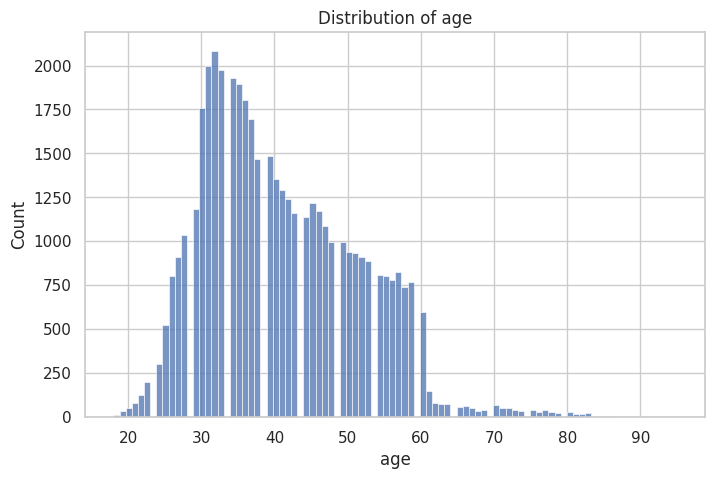

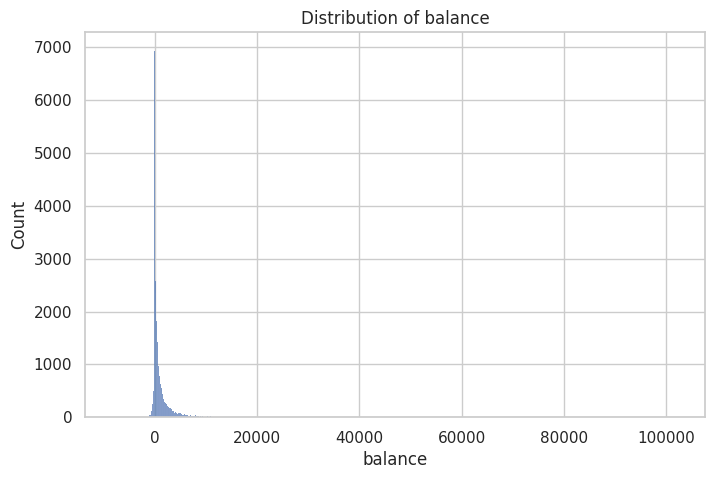

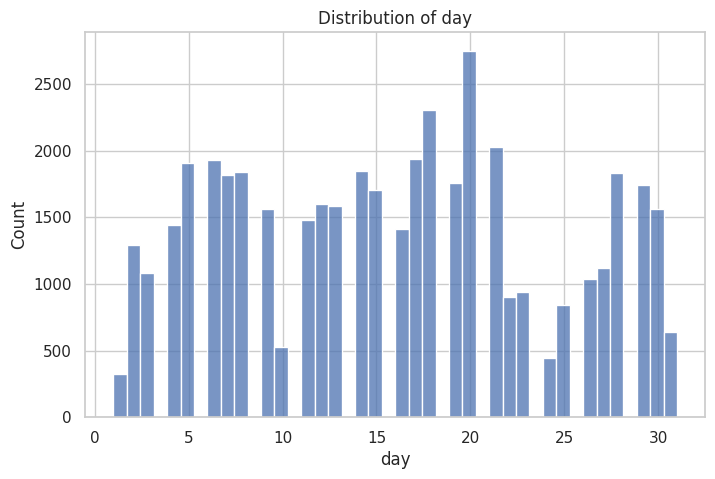

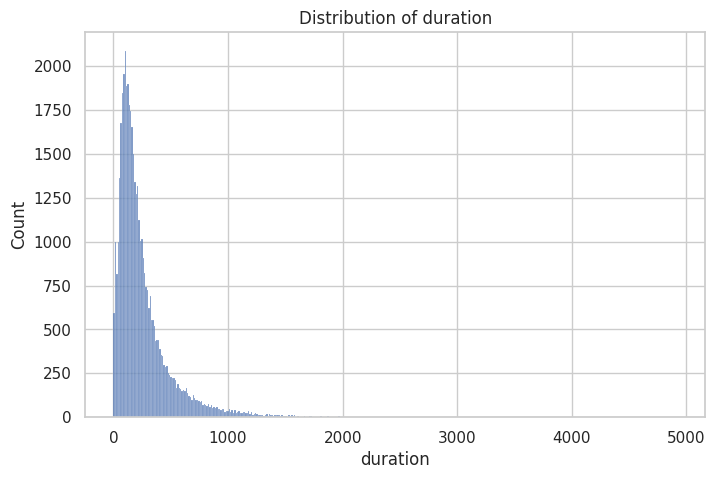

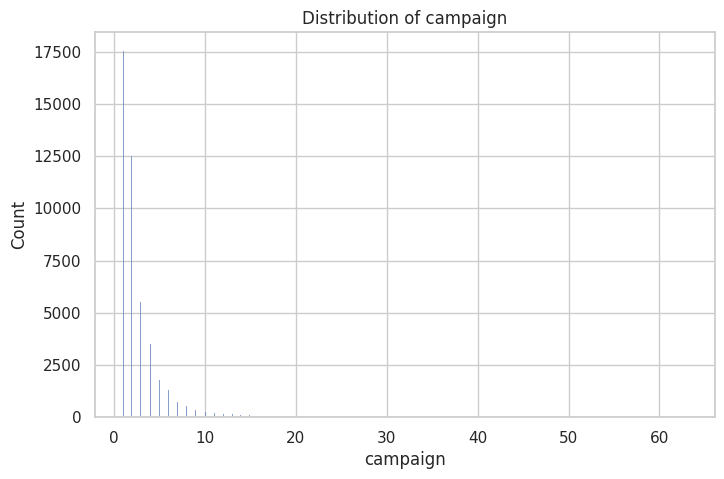

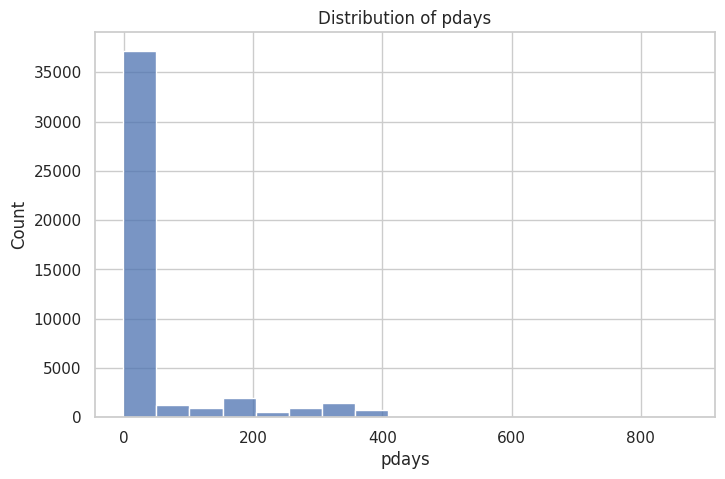

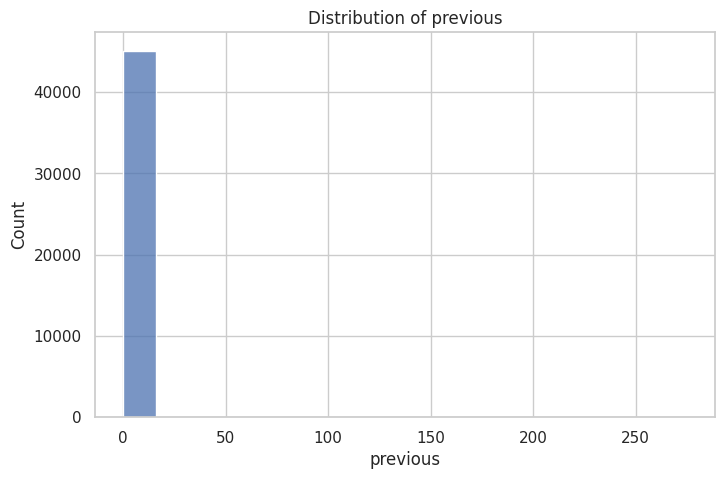

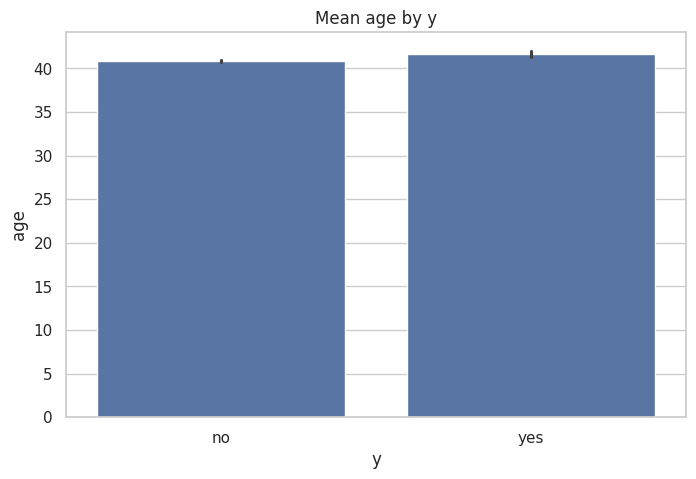

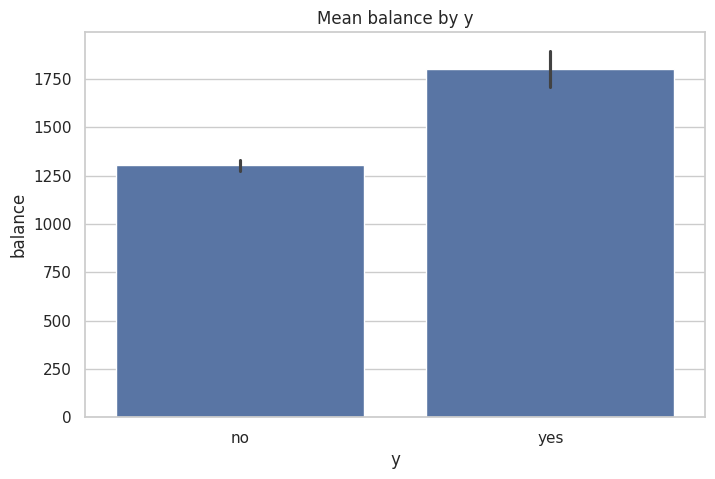

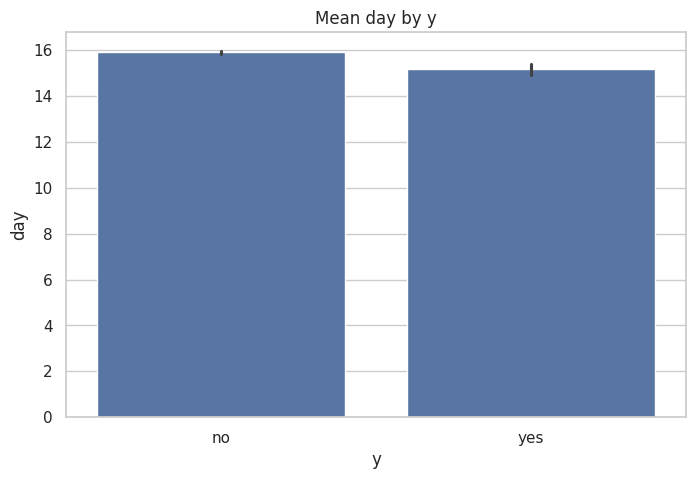

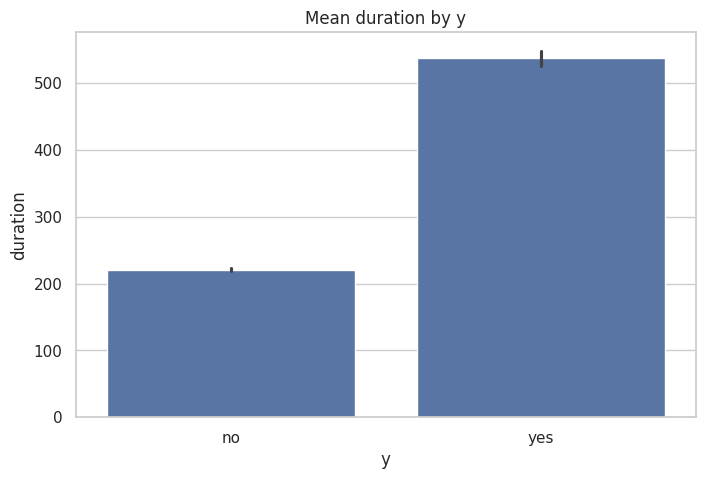

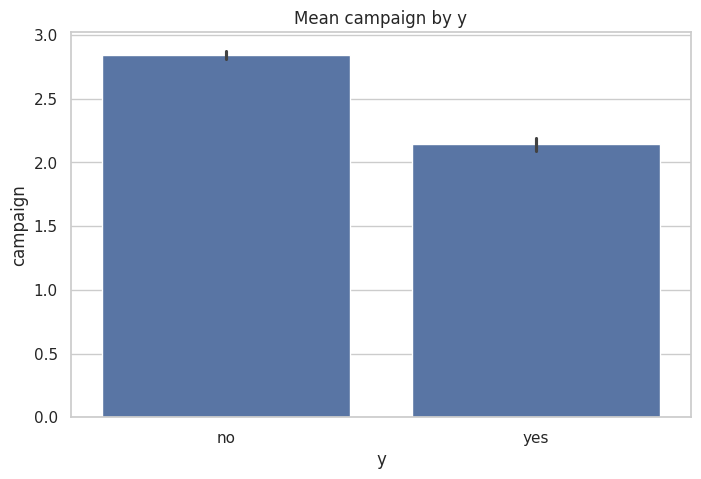

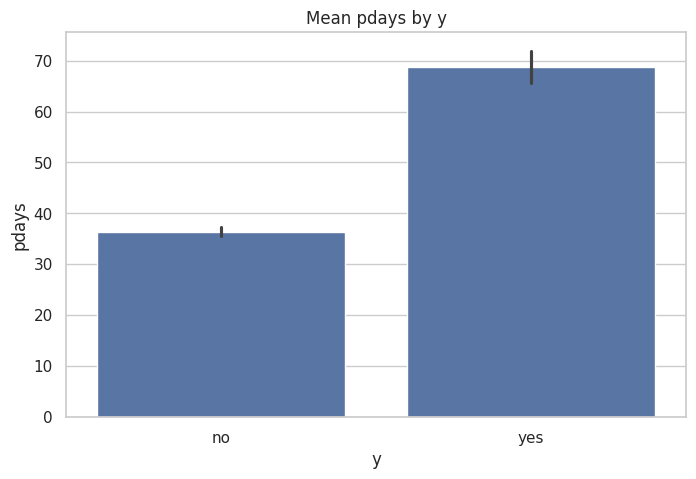

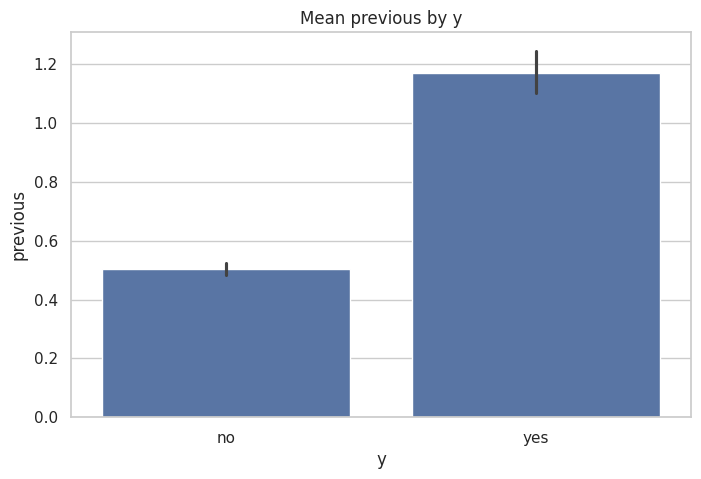

In [81]:
run_visual_eda(df)



1. Clientes que contrataram deposito a prazo, apresentam, em média, balance (saldo médio anual em euros) maior do que aqueles que não aceitaram

2. Clientes que NÃO contrataram deposito a prazo, apresentam, em média, campaign (num contatos durante essa campanha) maior do que aqueles que aceitaram

3. Clientes que contrataram deposito, apresentam, em média, pdays (num dias desde o ultimo contato) maior do que aqueles que não aceitaram - mas ao analisar o histograma vemos quee para maioria dos clientes essa variável possui valor zero e entendemos que está impactando na média. Sendo assim, clientes que contratram - obs: na análise descritiva vemos que a maioria das ocorrencias para esse campo são de valor igual a -1 (cliente não foi contactado anteriormente)
Logo, esses valores afetam a média avaliada.

4. Clientes que contrataram deposito, apresentam, em média, previous(num contato antes dessa campanha) maior do que aqueles que não aceitaram - obs.: na análise descritiva vimos que a maioria das ocorrencias para esse campo são de valor igual a 0 (zero contatos)
Logo, esses valores afetam a média avaliada.

5. Veja que claramente para idade os intervalos de confiança se sobrepoem - forte evidencia de que não há diferença entre as médias

obs.: Se os intervalos não se sobrepoem muito, há forte evidencias de que as medias de x para quem aceitou e quem nao aceitou são estatisticamente diferentes

6. Importante identificar que temos classes desbalancedas, sendo a majoritaria -> y = no (clientes que não contratam depósito a prazo) - ver método para balanceamento e métricas relevantes





# Quais os 3 principais fatores que levam a contratação de um depósito a prazo?

Para uma primeira visualização, ainda sem teste estatítico, vamos identificar fortes variáveis candidatas utilizando heatmap (combinando numéricas e categóricas)

In [82]:
def statistical_heatmap(df, target="y"):

    df_temp = df.copy()
    df_temp[target] = df_temp[target].map({"yes":1, "no":0})

    associations = {}

    for col in df_temp.columns:
        if col == target:
            continue

        if df_temp[col].dtype in ["int64", "float64"]:
            corr, _ = pointbiserialr(df_temp[target], df_temp[col])
            associations[col] = abs(corr)

        else:
            contingency = pd.crosstab(df_temp[col], df_temp[target])
            chi2, _, _, _ = chi2_contingency(contingency)

            n = contingency.sum().sum()
            r, k = contingency.shape
            cramers_v = np.sqrt(chi2 / (n * (min(k-1, r-1))))

            associations[col] = cramers_v

    assoc_series = pd.Series(associations).sort_values(ascending=False)

    plt.figure(figsize=(8,10))
    sns.heatmap(
        assoc_series.to_frame(name="Association with Target"),
        annot=True,
        cmap="viridis"
    )

    plt.title("Mapa de Calor — Força de Associação com a Target")
    plt.show()

    return assoc_series

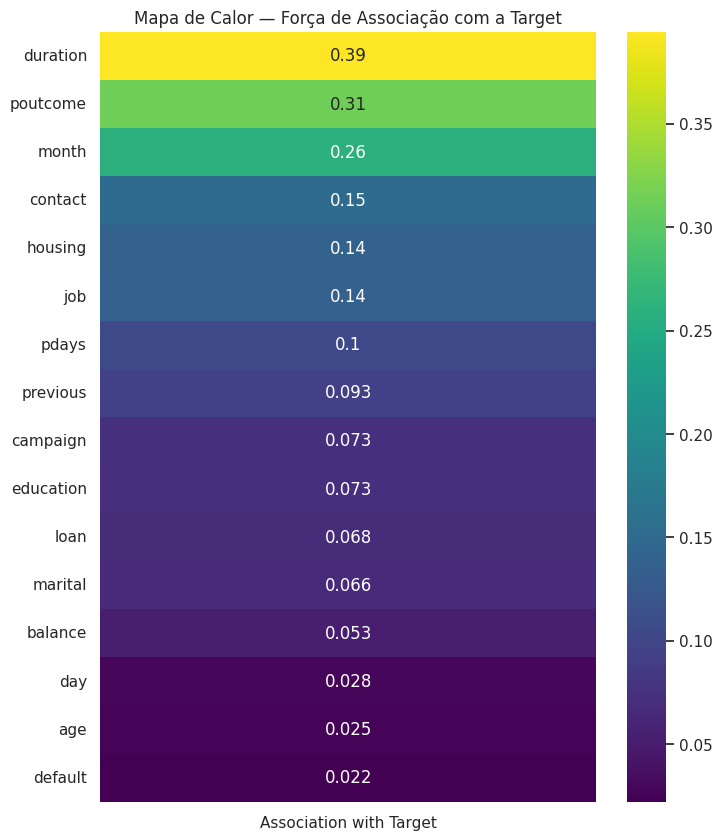

In [83]:
assoc_ranking = statistical_heatmap(df)

Essa foi uma análise de associação estatística, não implica causa. Então, por associação, os principais fatores que relacionados a contratação de depósito a prazo são duration (mas já sabemos que não podemos considerá-la em um caso de predição), poutcome (resultado de campanhas anteriores), month e contact (tipo de contato utilizado).

Para confirmar se essas variáveis são realmente as  mais relevantes irei aplicar uma Regressão Logística, pois é um modelo facilmente interpretável e irá demonstrar se essas mesmas variaveis são relevante quando tratadas em conjunto.

In [84]:
df_temp = df.copy()

df_temp["y"] = df_temp["y"].map({"yes":1, "no":0})

df_temp = pd.get_dummies(df_temp, drop_first=True)


df_temp = df_temp.astype(float)

X = df_temp.drop("y", axis=1)
y = df_temp["y"]

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.238463
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45168
Method:                           MLE   Df Model:                           42
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3392
Time:                        00:06:12   Log-Likelihood:                -10781.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.5356      0.184    -13.803      0.000      -2.896      -2.176
ag

In [85]:
summary_df = model.summary2().tables[1]
summary_df = summary_df.drop("const", errors="ignore")
significant = summary_df[summary_df["P>|z|"] < 0.05].copy() #mantem apenas variaveis significativas
significant["Odds_Ratio"] = np.exp(significant["Coef."])
significant = significant.sort_values("Coef.", key=abs, ascending=False) #ordenar por impacto

print(" Variáveis mais relevantes:")
display(significant.head(10))


 Variáveis mais relevantes:


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],Odds_Ratio
poutcome_success,2.291056,0.082349,27.821231,2.401599e-170,2.129655,2.452457,9.885371
contact_unknown,-1.623217,0.073174,-22.183096,5.001575e-109,-1.766634,-1.479799,0.197263
month_mar,1.589891,0.119854,13.265217,3.683517e-40,1.354981,1.824800,4.903212
month_jan,-1.261719,0.121703,-10.367175,3.497104e-25,-1.500253,-1.023185,0.283167
month_oct,0.881437,0.108031,8.159129,3.374498e-16,0.669701,1.093174,2.414368
month_sep,0.874058,0.119498,7.314434,2.584679e-13,0.639847,1.108269,2.396617
month_nov,-0.873399,0.084410,-10.347083,4.314307e-25,-1.038839,-0.707958,0.417530
month_jul,-0.830796,0.077405,-10.733051,7.120550e-27,-0.982507,-0.679084,0.435703
month_aug,-0.693908,0.078475,-8.842423,9.366478e-19,-0.847715,-0.540100,0.499620
month_dec,0.691124,0.176683,3.911660,9.166396e-05,0.344832,1.037417,1.995958


Interpretando:

1. poutcome_sucess -> clientes em que resultado anterior foi sucess tem 888% - (988-1)*100 - maior chance de contratar do que quem não teve sucesso em campanhas anteriores. Entendemos que o histórico de resultados anteriores é o principal fator.

2. Contatos do tipo unknown tem -80,3%  (0,19-1)*100. Ou seja, quando o contato é desconhecido a cahnce de contratação é 80,3% menor do que quando é conhecido.
Necessário investir em enriquecer o canal, buscando contatos reais dos clientes, evitando unknown.

3. Campanhas em março possuem quase 390,3% mais chance de contratação do que as que não são realizadas em março. . Sugere sazonalidade forte

4.  Além disse, na sequancia das variaveis importantes, observamos mesese com efeito positivo (mar, oct, sep, dec) e meses com efeito negativo (jan, nov, jul, aug), isso nos mostra um padrão de sazonalidade.

5.  Confirmamos que  poutcome (resultado de campanhas anteriores), month e contact (tipo de contato utilizado) são realmente relevantes.

6.  Resumo das conclusões: poutcome_sucess é fator dominante, cantact do tipo unknown deve ser evitado, month demonstra forte sazonalidade, especialmente em março.

7. As variáveis relevantes estão mais voltadas para campanha e  relacionamento do que perfil do cliente.

8. A análise de regressão logística indica que o principal fator associado à contratação é o histórico de sucesso em campanhas anteriores.

9. O tipo de contato e o mês da campanha demonstram influência significativa, evidenciando forte componente sazonal e importância do canal de comunicação.

10. O sucesso de contratação depende mais de como e quando o banco aborda o cliente (histórico de campanha e contexto)

11. Entendemos que com a relevancia de poutcome_sucess, clientes que já fecharam contratação antes devem ser prioridade



Entendendo melhor o que está acontecendo em março

In [86]:
#verificar perfil médio por mês
df.groupby("month")["balance"].mean().sort_values(ascending=False)

,balance
month,
nov,2512.932997
dec,2315.672897
oct,2312.371274
mar,2046.228512
sep,1948.291883
jun,1608.222243
apr,1542.551160
aug,1427.701777
feb,1319.098905


In [87]:
pd.crosstab(df["month"], df["poutcome"])

poutcome,failure,other,success,unknown
month,,,,
apr,737,252,129,1814
aug,237,86,207,5717
dec,41,26,51,96
feb,529,252,143,1725
jan,289,145,64,905
jul,109,46,99,6641
jun,133,70,118,5020
mar,75,38,60,304
may,1687,591,236,11252


In [88]:
poutcome_table = pd.crosstab(df["month"], df["poutcome"], normalize="index")
poutcome_table["success"].sort_values(ascending=False)

,success
month,
dec,0.238318
sep,0.227979
oct,0.177507
mar,0.125786
feb,0.053983
jan,0.045617
apr,0.043997
nov,0.035516
aug,0.033136


Interpretando os resultados:

Verificando proporção de histórico positivo (por mês)

Com coeficiente positivo
1. Março
failure: 75
success:60
unknow: 304
other: 38
total: 477
taxa de sucesso: 60/477 = 12.6%


2. Outubro
failure: 147
success:131
unknow: 399
other: 67
total: 744
taxa de sucesso: 131/744 = 17.7%

3. Setembro
failure: 120
success:132
unknow: 266
other: 61
total: 579
taxa de sucesso: 132/579 = 22.8%


Com coeficiente negativo
4. Janeiro
failure: 289
success:64
unknow: 905
other: 145
total: 1403
taxa de sucesso: 64/1403 = 4.6%


* Peguei o mês de janeiro como referência comparativa por apresentar grande volume de observações e baixa taxa de sucesso, servindo como contraponto para os meses com alta taxa de conversão, como é o caso de setembro, outubro e março.

* Então se esses meses foram apontados com efeito positivo em seus coeficientes e além disso, verificamos que esses meses possuem maior proporção de taxa de sucesso/poutcome_success, logo, parte do efeito da variável mês pode estar sendo explicado pela maior presença de clientes com histórico de sucesso nesses meses. Seria então uma combinação de sazonalidade x estratégias do banco?

* Vamos então testar um modelo sem a variável poutcome, e verificar se os coeficientes de month mudam:


In [89]:
[col for col in X.columns if "poutcome" in col]

X_sem_poutcome = X.drop(
    columns=[col for col in X.columns if "poutcome" in col],
    errors="ignore"
)

model2 = sm.Logit(y, X_sem_poutcome).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.251365
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45171
Method:                           MLE   Df Model:                           39
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3035
Time:                        00:07:22   Log-Likelihood:                -11364.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.6289      0.157    -16.754      0.000      -2.936      -2.321
ag

Comparar os coeficientes de month nos dois modelos

In [90]:
coef_model1 = model.params.filter(like="month")
coef_model2 = model2.params.filter(like="month")

comparacao = pd.DataFrame({
    "Com_poutcome": coef_model1,
    "Sem_poutcome": coef_model2
})

display(comparacao)

,Com_poutcome,Sem_poutcome
month_aug,-0.693908,-0.621234
month_dec,0.691124,0.978284
month_feb,-0.147321,-0.068452
month_jan,-1.261719,-1.193871
month_jul,-0.830796,-0.769509
month_jun,0.453623,0.574594
month_mar,1.589891,1.624215
month_may,-0.399111,-0.356360
month_nov,-0.873399,-0.797219
month_oct,0.881437,1.042503


Comparar Odds Ratios

In [91]:
comparacao_or = pd.DataFrame({
    "OR_com_poutcome": np.exp(coef_model1),
    "OR_sem_poutcome": np.exp(coef_model2)
})

display(comparacao_or)

,OR_com_poutcome,OR_sem_poutcome
month_aug,0.499620,0.537281
month_dec,1.995958,2.659888
month_feb,0.863017,0.933838
month_jan,0.283167,0.303046
month_jul,0.435703,0.463240
month_jun,1.574004,1.776409
month_mar,4.903212,5.074433
month_may,0.670916,0.700220
month_nov,0.417530,0.450580
month_oct,2.414368,2.836309


1. Vemos então que não temos uma Odds Ratio muito diferente para o modelo sem poutcome, temos mudanças moderadas.

2. Aqui, vemos que o efeito do mês não é apenas reflexo do histórico anterior, ou seja, embora exista associação entre mês e histórico, o efeito do mês permanece significativo mesmo apo´s retirada da variável poutcome, indicando influência temporal independente.Mostrando que não é apenas seleção de cliente, existe sim sazonalidade. Existe algo relacionado a campanha ou até um comportamento econômico.

3. Isso sugere que parte da sazonalidade é independente da campanha

4. Sazonalidade pode refletir tanto comportamento do cliente quanto estratégia do banco


Conforme enunciado, agora vou treinar um modelo sem os principais fatores identificados e comparar (Sem poutcome, month, contact)

In [92]:
cols_remove = [col for col in X.columns
               if ("poutcome" in col)
               or ("month" in col)
               or ("contact" in col)]

X_model3 = X.drop(columns=cols_remove, errors="ignore")
model3 = sm.Logit(y, X_model3).fit()
print(model3.summary())


Optimization terminated successfully.
         Current function value: 0.271147
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45184
Method:                           MLE   Df Model:                           26
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.2486
Time:                        00:07:46   Log-Likelihood:                -12259.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.8951      0.139    -20.802      0.000      -3.168      -2.622
ag

# Comparando os três modelos

In [93]:
vars_comuns_123 = list(
    (set(model.params.index) &
     set(model2.params.index) &
     set(model3.params.index))
)

vars_comuns_123 = [v for v in vars_comuns_123 if v != "const"]

comparacao_or_123 = pd.DataFrame({
    "OR_Model1": np.exp(model.params[vars_comuns_123]),
    "OR_Model2": np.exp(model2.params[vars_comuns_123]),
    "OR_Model3": np.exp(model3.params[vars_comuns_123])
})

display(comparacao_or_123.sort_values("OR_Model3", ascending=False))

,OR_Model1,OR_Model2,OR_Model3
job_student,1.465411,1.527463,1.833696
education_tertiary,1.460738,1.571453,1.742147
job_retired,1.287063,1.280054,1.432653
education_unknown,1.284640,1.339959,1.327376
marital_single,1.096911,1.136906,1.253207
education_secondary,1.201449,1.244512,1.250736
previous,1.010204,1.059185,1.079864
duration,1.004203,1.004163,1.003944
age,1.000113,1.001987,1.003304
pdays,0.999897,1.001323,1.002879


1. Quando removemos fatores dominants relacionados a campanha e relacionamento, variáveis relacionadas a perfil ganham importância, como: job (tipo de trabalho),  educação, estado civil, se possui financiamento ativo(default).
2. Já sabemos que as variáveis relacionadas a campanha em relacionamento indicam possibilidade de estratégias nessa linha
3. Vimos também que existe espaço para segmentação baseada em perfil
4. Posso propor 2 cenários de estratégias para equipe de marketing:
  - ter um modelo preditivo baseada em campanhas e relacionamentos
  - ter um modelo baseado em perfil
  Sendo assim, irei definir um teste A/B. Farei.
  Para simulação, vou utilizar nossa base para estimar, com intuito de demonstrar um experimento que auxilie na tomada de decisão.


Sobre o teste/AB

* Primeiro irei retirar a variável duration no treino do modelo1 e também no modelo3. Lembrando que modelo1 será utilizado em estratégias voltadas para campanha e relacionamento e modelo3 pode ser utilizado para estratégias voltadas para perfil de clientes.

# Remover variável duration e treinar modelos - agora fazendo split dos dados, pois também irei olhar performance e não somente os coeficiente


In [94]:
#Remover duration

df_clean = df.copy()

df_clean["y"] = df_clean["y"].map({"yes": 1, "no": 0})

df_clean = df_clean.drop(columns=["duration"], errors="ignore")

df_encoded = pd.get_dummies(df_clean, drop_first=True)

df_encoded = df_encoded.astype(float)

X_new = df_encoded.drop("y", axis=1)
y_new = df_encoded["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)


X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)



In [95]:
#Retreino modelo1
model1_new = sm.Logit(y_train, X_train).fit()
print(model1_new.summary())

Optimization terminated successfully.
         Current function value: 0.300847
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                36168
Model:                          Logit   Df Residuals:                    36126
Method:                           MLE   Df Model:                           41
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.1663
Time:                        00:09:18   Log-Likelihood:                -10881.
converged:                       True   LL-Null:                       -13052.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.3173      0.182     -7.222      0.000      -1.675      -0.960
ag

In [224]:
#Retreino modelo3
cols_remove = ["duration","poutcome", "month", "contact"]


df_clean = df.copy()

df_clean["y"] = df_clean["y"].map({"yes": 1, "no": 0})

df_clean = df_clean.drop(columns=cols_remove, errors="ignore")

df_encoded = pd.get_dummies(df_clean, drop_first=True)

df_encoded = df_encoded.astype(float)

X_new = df_encoded.drop("y", axis=1)
y_new = df_encoded["y"]


X_train_m3, X_test_m3, y_train, y_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

X_train_m3 = sm.add_constant(X_train_m3)
X_test_m3 = sm.add_constant(X_test_m3)


model3_new = sm.Logit(y_train, X_train_m3).fit()
print(model3_new.summary())



Optimization terminated successfully.
         Current function value: 0.332062
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                36168
Model:                          Logit   Df Residuals:                    36142
Method:                           MLE   Df Model:                           25
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.07983
Time:                        02:51:04   Log-Likelihood:                -12010.
converged:                       True   LL-Null:                       -13052.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.6709      0.138    -12.103      0.000      -1.941      -1.400
ag

# Calculando AUC para os modelos

In [225]:
#Calculando AUC para os modelos

# Modelo1
prob1 = model1_new.predict(X_test)
auc1 = roc_auc_score(y_test, prob1)

# Modelo3
prob3 = model3_new.predict(X_test_m3)
auc3 = roc_auc_score(y_test, prob3)

print("AUC Modelo 1:", auc1)
print("AUC Modelo 3:", auc3)

AUC Modelo 1: 0.7717136218311035
AUC Modelo 3: 0.7097631073385471


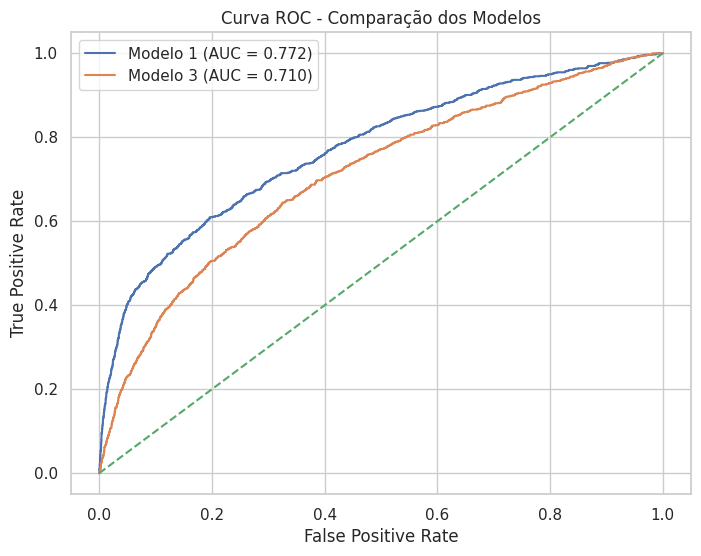

In [226]:
fpr1, tpr1, _ = roc_curve(y_test, prob1)
fpr3, tpr3, _ = roc_curve(y_test, prob3)

auc1 = roc_auc_score(y_test, prob1)
auc3 = roc_auc_score(y_test, prob3)

plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label=f"Modelo 1 (AUC = {auc1:.3f})")
plt.plot(fpr3, tpr3, label=f"Modelo 3 (AUC = {auc3:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparação dos Modelos")
plt.legend()
plt.show()

1. Variáveis relacionadas a campanha e relacionamento aumentam a capacidade preditiva do modelo (modelo1). Melhor considerar campanha do que perfil isoladamente.
2. Com o estudo, entendo que:
  -Se o objetivo é maximizar contratações na próxima campanha (curto prazo), ou seja, eficiência imediata: usar modelo1

   -Se o objetivo é construtuir segmentação estrutural, ou melhor, crescimento estrutural, expandindo a base de clientes contratantes: usar modelo3, pois perfil é mais importante


# Retomando o assunto teste A/B

Vou realizar uma simulação histórica para um teste A/B, farei isso pois temos duas estratégias possíveis, usar uma base histórica única e temos observações reais. A ideia é entender como os modelos se comportariam caso tivessem sido aplicados no passado. Ex.: Se tivéssemos usado o modelo1 no lugar do modelo3 teríamos mais clientes fechando contrato?

In [227]:
#Gerar probabilidade de contratação/conversão para cada cliente
#maior score-> maior probabilidade de conversão

y_test = y_test.reset_index(drop=True)
prob1 = prob1.reset_index(drop=True)
prob3 = prob3.reset_index(drop=True)

df_ab = pd.DataFrame({
    "y": y_test.values,
    "score_m1": prob1,
    "score_m3": prob3
})

# Top 20%
n = int(len(df_ab) * 0.2)

grupo_A = df_ab.sort_values("score_m1", ascending=False).head(n)
grupo_B = df_ab.sort_values("score_m3", ascending=False).head(n)

conv_A = grupo_A["y"].mean()
conv_B = grupo_B["y"].mean()

print("Conversão Grupo A (Modelo 1):", round(conv_A,4))
print("Conversão Grupo B (Modelo 3):", round(conv_B,4))

Conversão Grupo A (Modelo 1): 0.3258
Conversão Grupo B (Modelo 3): 0.2666


In [228]:
print("y_test:", len(y_test))
print("prob1:", len(prob1))
print("prob3:", len(prob3))

y_test: 9043
prob1: 9043
prob3: 9043


In [229]:
df_ab.head(5)

,y,score_m1,score_m3
0,0.0,0.013179,0.026382
1,0.0,0.025515,0.055634
2,0.0,0.035859,0.038511
3,0.0,0.017208,0.032693
4,0.0,0.132343,0.090428


In [221]:
#Teste estatístico de proporção

conversions = [
    grupo_A["y"].sum(),
    grupo_B["y"].sum()
]

nobs = [len(grupo_A), len(grupo_B)]

z_stat, p_value = proportions_ztest(conversions, nobs)

print("Z-stat:", z_stat)
print("p-value:", p_value)

Z-stat: -4.092132854444592
p-value: 4.2742364174720204e-05


\\ temos p-value <0.05, a diferença de conversão entre os dois modelos é estatisticamente significativa.

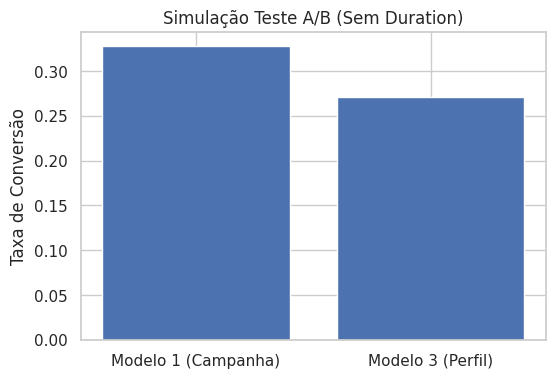

In [ ]:
#Visualizando as taxas de conversão nos dois modelos


plt.figure(figsize=(6,4))
plt.bar(["Modelo 1 (Campanha)", "Modelo 3 (Perfil)"],
        [conv_A, conv_B])

plt.ylabel("Taxa de Conversão")
plt.title("Simulação Teste A/B (Sem Duration)")
plt.show()

A simulação indicou que se a estratégia for baseada no modelo1 (considera campanha e relacionamento) a taxa de conversão  será maior.

Então temos 32% de taxa de conversão para o modelo1 e 27% para o modelo3. Entendendo melhor:

* supondo que entramos em contato e 10.000 clientes fecharam
* supondo ticket médio de R$ 5.000
  *  Para o modelo1 temos: 10.000 x 32% = 3200 contratos fechados
  *  Para o modelo3 temos: 10.000 x 27% = 2700 contratos fechados
  * diferença de 500 contratos adicionais






1. Logo, a estratégia baseada no modelo1 apresenta ganho estatisticamente significativo e economicamente relevante.

2. Lembrando que a estratégia baseada no modelo1 (campanha e relacionamento) busca maximizar a taxa de conversão a curto prazo. A abordagem do modelo3 (perfil de clientes) visa mudança estrutural, pensando em sustentabilidade e expansão a longo prazo

3. A recomendação seria uma avordagem híbrida,não é apenas otimizar a próxima campanha, mas estruturar uma estratégia sustentável ao longo do tempo. Sugestão de implementação de uma abordagem híbrida:
 * 3.1  Usar modelo1 (campanha) para clientes já trabalhados, ativos e remarketing
 * 3.2 Usar modelo3 (perfil) para clientes sem histórico e aquisição de novos clientes  

4. A abordagem nos permite concentrar esforço nos clientes com maior probabilidade, aumentando eficiência da campanha sem necessariamente aumentar custo.

# E como está a taxa de conversão atual?

In [ ]:
taxa_base = (df["y"] == "yes").mean()
print(round(taxa_base,4))

0.117


In [ ]:
Questão: Fale sobre as dificuldades que o modelo construído poderia ter para alcançar o sucesso esperado pelo treino em um novo dataset.

* O modelo apresenta boa performance no dataset de treino, mas sua generalização depende da estabilidade do contexto operacional e do comportamento do cliente.
* É necessário monitoramento contínuo, validação temporal e retreino periódico para manter robustez ao longo do tempo.
* Podemos nos deparar com mudanças nas didtribuições do dados se o perfil do cliente mudar ou até mesmo ocorrer mudança do público alvo.
* Um mês históricamente com alta taxa de conversão pode deixar de ter, podem surgir novos canais de ContextDecorator
* Mesmo com AUC boa, o modelo po ter capturado padrões muito esécíficos de determinado período, em um novo cenário esses padões podem não acontecer. Além disso,
precisamos acompanhar não só métricas de desempenho do modelo mas ganho operacional e impacto financeiro.